# Project: Credit Scoring Model

**Objective:** Build a model that predicts whether a person is likely to default on a loan (miss payments badly) in the next 2 years, using their financial history.

**Dataset:** Give Me Some Credit a real dataset from a 2011 Kaggle Competition with 150,000 people's financial records


**Approach:**
1. Clean the data (fix bad values, fill in missing values)
2. Create some new features from the payment history and financial ratios
3. Train two classification models: Logistic Regression and Random Forest and compare them
4. Check how well each model actually works using proper metrics
5. Figure out which features matter most for predicting default
6. Evaluate using Precision, Recall, F1-Score, and ROC-AUC

## 1. Setup & Data Loading
First I import the libraries I'll need and load the datasets.

In [8]:
!pip install xgboost shap --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, recall_score, precision_score
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

dataset_path = glob.glob("/kaggle/input/**/cs-training.csv", recursive=True)[0]
df = pd.read_csv(dataset_path, index_col=0)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_%": (df.isnull().sum() / len(df) * 100).round(2)
})
summary

Dataset loaded: 150,000 rows x 11 columns



,dtype,missing,missing_%
SeriousDlqin2yrs,int64,0,0.00
RevolvingUtilizationOfUnsecuredLines,float64,0,0.00
age,int64,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.00
DebtRatio,float64,0,0.00
MonthlyIncome,float64,29731,19.82
NumberOfOpenCreditLinesAndLoans,int64,0,0.00
NumberOfTimes90DaysLate,int64,0,0.00
NumberRealEstateLoansOrLines,int64,0,0.00
NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.00


## 2. Exploring the Data
Before I clean or change anything, I want to look at the raw data first
how many people actually defaulted, what the age range looks like, and 
whether anything looks obviously wrong.

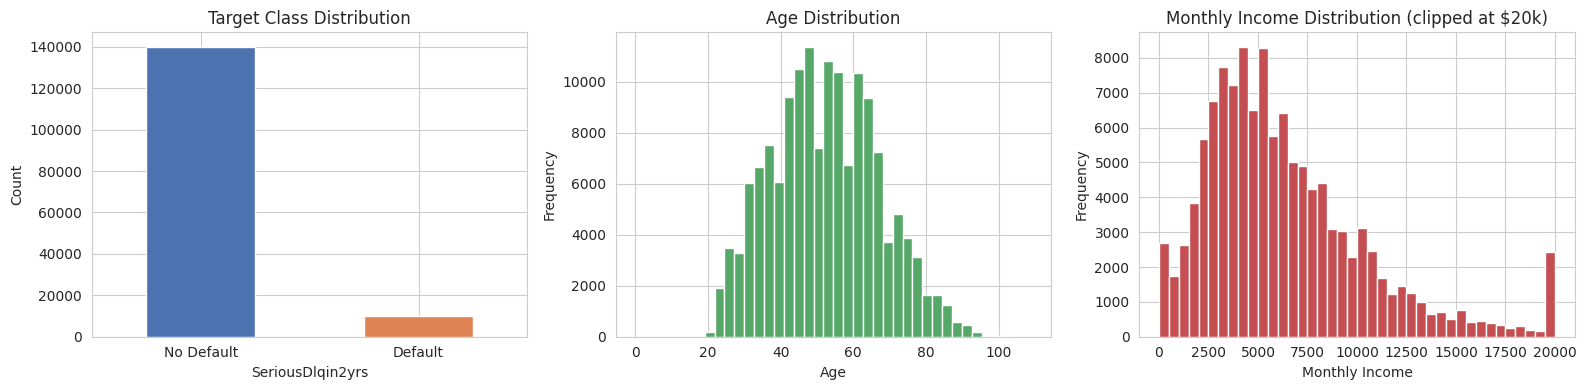

Overall default rate: 6.68%
Age range: 0 to 109 (note: minimum of 0 is invalid, addressed in cleaning)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["SeriousDlqin2yrs"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Target Class Distribution")
axes[0].set_xticklabels(["No Default", "Default"], rotation=0)
axes[0].set_ylabel("Count")

df["age"].plot(kind="hist", bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")

df["MonthlyIncome"].clip(upper=20000).plot(kind="hist", bins=40, ax=axes[2], color="#C44E52")
axes[2].set_title("Monthly Income Distribution (clipped at $20k)")
axes[2].set_xlabel("Monthly Income")

plt.tight_layout()
plt.show()

default_rate = df["SeriousDlqin2yrs"].mean()
print(f"Overall default rate: {default_rate:.2%}")
print(f"Age range: {df['age'].min()} to {df['age'].max()} (note: minimum of 0 is invalid, addressed in cleaning)")

## 3. Cleaning the Data
From exploring the data, I found 3 problems I need to fix:

1. **Invalid age = 0** — that's not possible, so it must be an error
2. **Some late-payment columns have values like 96 or 98** — real people 
   aren't "96 times late," so these look like placeholder error codes, not 
   real numbers
3. **Some values are missing** — about 20% of `MonthlyIncome` and 2.6% of 
   `NumberOfDependents` are empty

I fix each one below and explain how.

In [10]:
invalid_age_count = (df["age"] == 0).sum()
df.loc[df["age"] == 0, "age"] = df["age"].median()

late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]
glitch_count = df[late_cols[0]].isin([96, 98]).sum()

for col in late_cols:
    median_val = df[df[col] < 90][col].median()
    df.loc[df[col].isin([96, 98]), col] = median_val

age_bins = [0, 30, 40, 50, 60, 70, 120]
age_labels = ["<30", "30-40", "40-50", "50-60", "60-70", "70+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

income_missing_count = df["MonthlyIncome"].isnull().sum()
df["MonthlyIncome"] = df.groupby("age_group")["MonthlyIncome"].transform(lambda x: x.fillna(x.median()))

dependents_missing_count = df["NumberOfDependents"].isnull().sum()
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

cleaning_summary = pd.DataFrame({
    "Issue": [
        "Invalid age (age=0)",
        "Placeholder glitch values (96/98)",
        "Missing MonthlyIncome",
        "Missing NumberOfDependents"
    ],
    "Records Affected": [
        invalid_age_count, glitch_count, income_missing_count, dependents_missing_count
    ],
    "Fix Applied": [
        "Replaced with median age",
        "Replaced with column median (excl. glitch values)",
        "Imputed using age-group median income",
        "Imputed with 0"
    ]
})
cleaning_summary

,Issue,Records Affected,Fix Applied
0,Invalid age (age=0),1,Replaced with median age
1,Placeholder glitch values (96/98),269,Replaced with column median (excl. glitch values)
2,Missing MonthlyIncome,29731,Imputed using age-group median income
3,Missing NumberOfDependents,3924,Imputed with 0


## 4. Creating New Features
When I checked correlations earlier, I noticed the three late-payment 
columns are related to each other (if someone is late 30-59 days, they're 
often also late 60-89 days). So instead of keeping them separate, I combined 
them into one total. I also created a couple of other features based on 
things that make sense for credit risk, like income per dependent.

In [11]:
df["TotalTimesLate"] = df[late_cols].sum(axis=1)
df["HasBeenLate"] = (df["TotalTimesLate"] > 0).astype(int)
df["TotalCreditLines"] = df["NumberOfOpenCreditLinesAndLoans"] + df["NumberRealEstateLoansOrLines"]
df["IncomePerDependent"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

if "age_group" in df.columns:
    df = pd.get_dummies(df, columns=["age_group"], prefix="age", drop_first=True)

new_features = pd.DataFrame({
    "Feature": ["TotalTimesLate", "HasBeenLate", "TotalCreditLines", "IncomePerDependent"],
    "Description": [
        "Sum of all late-payment counts across the three original columns",
        "Binary flag: 1 if ever late, 0 otherwise",
        "Combined open credit lines and real estate loans",
        "Monthly income divided by (dependents + 1)"
    ],
    "Correlation with Target": [
        df[["TotalTimesLate", "SeriousDlqin2yrs"]].corr().iloc[0, 1],
        df[["HasBeenLate", "SeriousDlqin2yrs"]].corr().iloc[0, 1],
        df[["TotalCreditLines", "SeriousDlqin2yrs"]].corr().iloc[0, 1],
        df[["IncomePerDependent", "SeriousDlqin2yrs"]].corr().iloc[0, 1],
    ]
})
new_features["Correlation with Target"] = new_features["Correlation with Target"].round(4)
new_features

,Feature,Description,Correlation with Target
0,TotalTimesLate,Sum of all late-payment counts across the thre...,0.3887
1,HasBeenLate,"Binary flag: 1 if ever late, 0 otherwise",0.3069
2,TotalCreditLines,Combined open credit lines and real estate loans,-0.0280
3,IncomePerDependent,Monthly income divided by (dependents + 1),-0.0274


## 5. Checking Correlations
Now that cleaning and feature engineering are done, I want to see how every 
feature old and new relates to whether someone defaults.

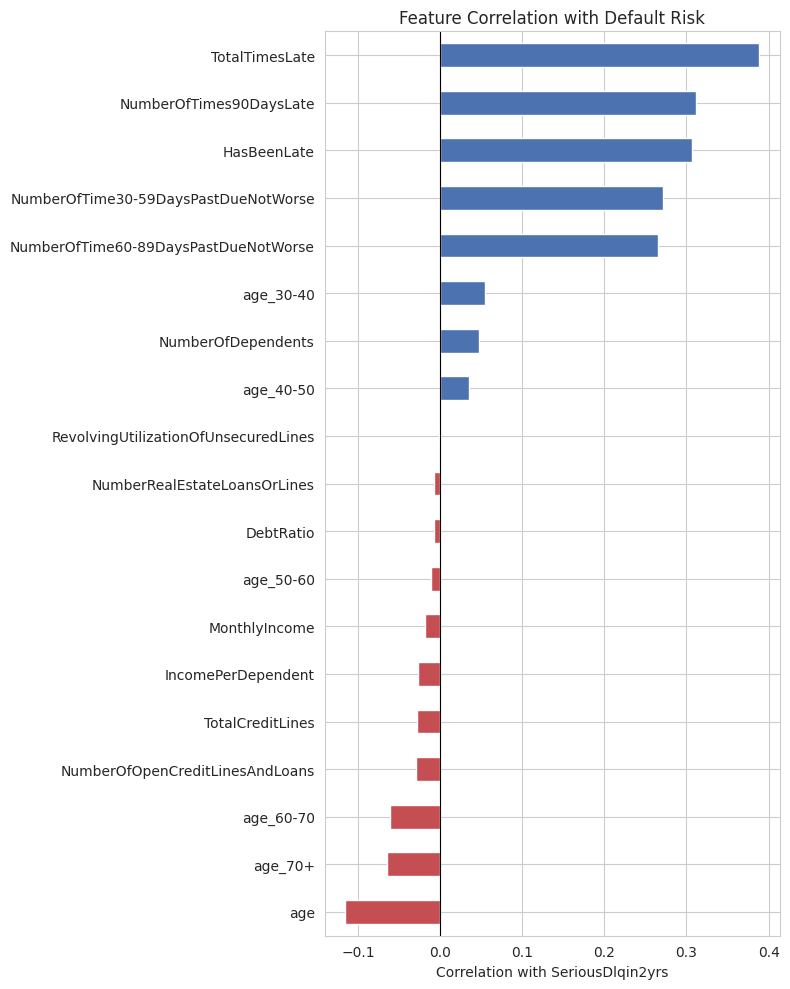

Strongest positive predictor: TotalTimesLate (0.3887)
Strongest negative predictor: age (-0.1154)


In [12]:
plt.figure(figsize=(8, 10))
correlations = df.corr()["SeriousDlqin2yrs"].drop("SeriousDlqin2yrs").sort_values()
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in correlations.values]
correlations.plot(kind="barh", color=colors)
plt.title("Feature Correlation with Default Risk")
plt.xlabel("Correlation with SeriousDlqin2yrs")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"Strongest positive predictor: {correlations.idxmax()} ({correlations.max():.4f})")
print(f"Strongest negative predictor: {correlations.idxmin()} ({correlations.min():.4f})")

## 6. Splitting the Data
Before training any model, I split the data into a training set (used to 
teach the model) and a validation set (used to test it on data it hasn't 
seen). I used `stratify=y` so both sets have the same percentage of 
defaulters otherwise the validation set might end up with too few 
default cases to test properly.

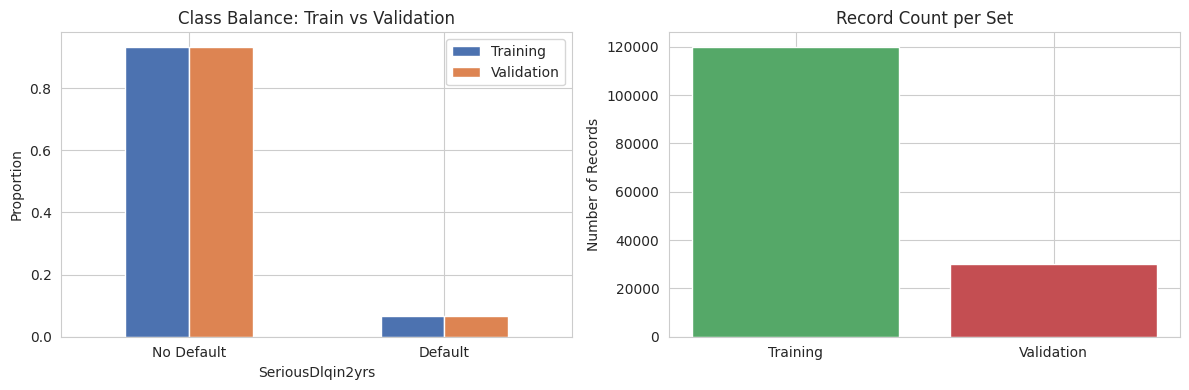

,Set,Records,Default Rate
0,Training,120000,0.0668
1,Validation,30000,0.0668


In [13]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

split_summary = pd.DataFrame({
    "Set": ["Training", "Validation"],
    "Records": [X_train.shape[0], X_val.shape[0]],
    "Default Rate": [y_train.mean(), y_val.mean()]
})
split_summary["Default Rate"] = split_summary["Default Rate"].round(4)

comparison = pd.DataFrame({
    "Training": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True)
})
comparison.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class Balance: Train vs Validation")
axes[0].set_xticklabels(["No Default", "Default"], rotation=0)
axes[0].set_ylabel("Proportion")

axes[1].bar(["Training", "Validation"], [X_train.shape[0], X_val.shape[0]], color=["#55A868", "#C44E52"])
axes[1].set_title("Record Count per Set")
axes[1].set_ylabel("Number of Records")

plt.tight_layout()
plt.show()

split_summary

## 7. Model 1 — Logistic Regression
This is my baseline model. Logistic Regression works better when features 
are on the same scale, so I standardized the numbers first. I only fit the 
scaler on the training data (not the validation data) to avoid the model 
accidentally "cheating" by seeing information from the test set.

I also used `class_weight="balanced"` because only about 7% of people in 
this dataset actually defaulted — without this setting, the model could 
just predict "no default" for everyone and still look accurate.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_logreg = log_reg.predict(X_val_scaled)
y_proba_logreg = log_reg.predict_proba(X_val_scaled)[:, 1]
auc_logreg = roc_auc_score(y_val, y_proba_logreg)

print(classification_report(y_val, y_pred_logreg, target_names=["No Default", "Default"]))
print(f"ROC-AUC Score: {auc_logreg:.4f}")

              precision    recall  f1-score   support

  No Default       0.97      0.85      0.90     27995
     Default       0.23      0.65      0.34      2005

    accuracy                           0.83     30000
   macro avg       0.60      0.75      0.62     30000
weighted avg       0.92      0.83      0.87     30000

ROC-AUC Score: 0.8230


## 8. Model 2 — Random Forest
Random Forest is a tree-based model, so it doesn't need the scaling step 
Logistic Regression needed. I used the same `class_weight="balanced"` 
setting so both models are compared fairly.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]
auc_rf = roc_auc_score(y_val, y_proba_rf)

print(classification_report(y_val, y_pred_rf, target_names=["No Default", "Default"]))
print(f"ROC-AUC Score: {auc_rf:.4f}")

              precision    recall  f1-score   support

  No Default       0.98      0.82      0.89     27995
     Default       0.23      0.75      0.35      2005

    accuracy                           0.82     30000
   macro avg       0.61      0.79      0.62     30000
weighted avg       0.93      0.82      0.86     30000

ROC-AUC Score: 0.8659


## 9. Comparing Both Models
Now I put both models side by side to see which one actually performs 
better, and by how much.

In [16]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [auc_logreg, auc_rf],
    "Recall (Default)": [recall_score(y_val, y_pred_logreg), recall_score(y_val, y_pred_rf)],
    "Precision (Default)": [precision_score(y_val, y_pred_logreg), precision_score(y_val, y_pred_rf)]
}).round(4)

comparison_df["ROC-AUC Rank"] = comparison_df["ROC-AUC"].rank(ascending=False).astype(int)
comparison_df = comparison_df.sort_values("ROC-AUC Rank")

best_model_name = comparison_df.iloc[0]["Model"]
auc_gain = comparison_df["ROC-AUC"].max() - comparison_df["ROC-AUC"].min()
recall_gain = comparison_df["Recall (Default)"].max() - comparison_df["Recall (Default)"].min()

print(f"Best performing model: {best_model_name}")
print(f"ROC-AUC improvement over baseline: +{auc_gain:.4f}")
print(f"Recall improvement over baseline: +{recall_gain:.4f}")
comparison_df

Best performing model: Random Forest
ROC-AUC improvement over baseline: +0.0429
Recall improvement over baseline: +0.0967


,Model,ROC-AUC,Recall (Default),Precision (Default),ROC-AUC Rank
1,Random Forest,0.8659,0.7501,0.2324,1
0,Logistic Regression,0.8230,0.6534,0.2332,2


## 10. ROC Curve & Confusion Matrix
The ROC curve shows how good each model is at telling defaulters and 
non-defaulters apart, across every possible cutoff point not just one. 
The confusion matrix shows exactly how many predictions were right and 
wrong for the better model.

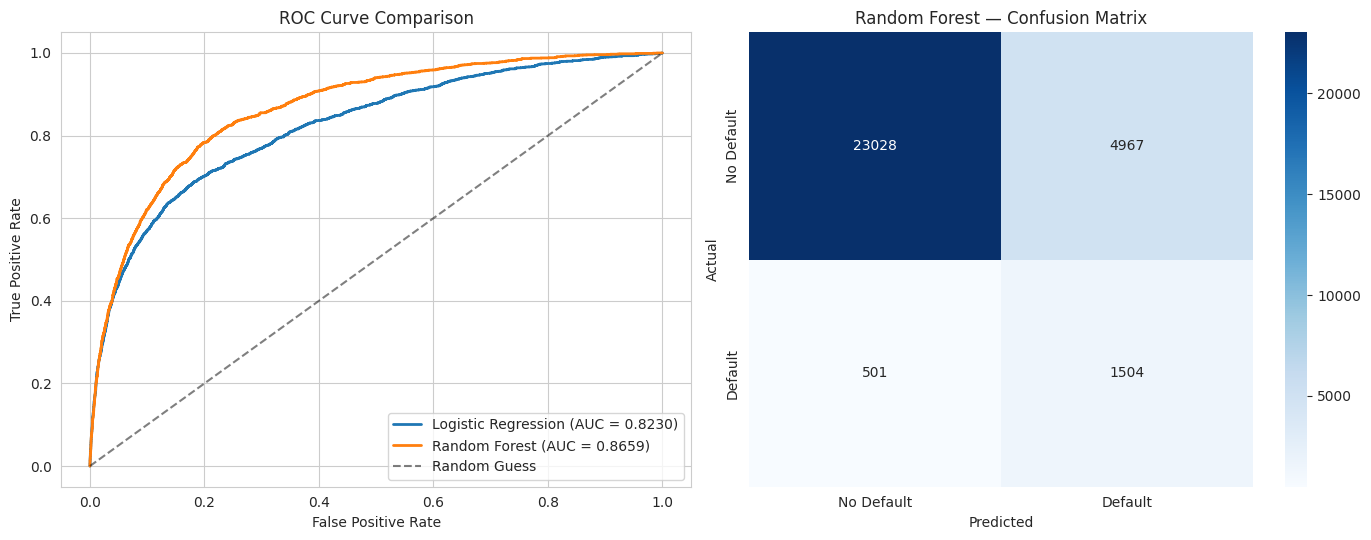

Defaulters correctly identified: 1504 out of 2005 (75.0%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_proba_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_proba_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_logreg:.4f})", linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", label="Random Guess", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison")
axes[0].legend(loc="lower right")

cm = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
    xticklabels=["No Default", "Default"], yticklabels=["No Default", "Default"]
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Random Forest — Confusion Matrix")

plt.tight_layout()
plt.show()

true_positives = cm[1, 1]
false_negatives = cm[1, 0]
print(f"Defaulters correctly identified: {true_positives} out of {true_positives + false_negatives} ({true_positives/(true_positives+false_negatives):.1%})")

## 11. Which Features Matter Most
Random Forest can tell me which features it relied on most to make its 
decisions. This is useful because it turns the model from a "black box" 
into something I can actually explain important in credit scoring, 
since lenders need to justify why someone was flagged as risky.

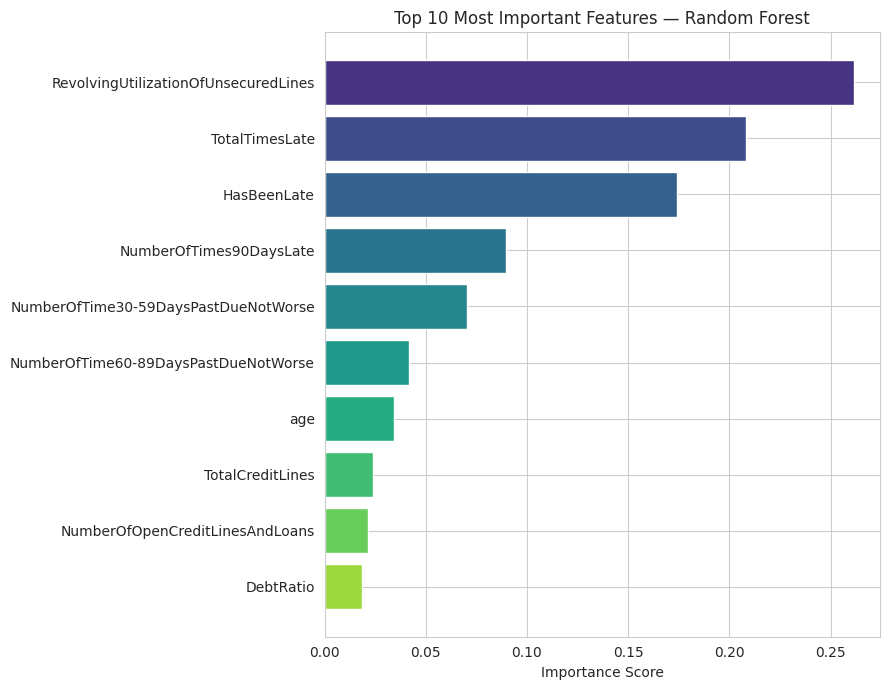

Top feature by model importance: RevolvingUtilizationOfUnsecuredLines (importance: 0.2613)
That same feature's linear correlation with target: -0.0018
The gap between importance rank and linear correlation suggests a non-linear
relationship — something Logistic Regression alone could not capture.


In [18]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
top10 = importances.head(10)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(top10)))
plt.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
plt.xlabel("Importance Score")
plt.title("Top 10 Most Important Features — Random Forest")
plt.tight_layout()
plt.show()

top_feature = importances.index[0]
top_feature_corr = df[[top_feature, "SeriousDlqin2yrs"]].corr().iloc[0, 1]
print(f"Top feature by model importance: {top_feature} (importance: {importances.iloc[0]:.4f})")
print(f"That same feature's linear correlation with target: {top_feature_corr:.4f}")
print("The gap between importance rank and linear correlation suggests a non-linear")
print("relationship — something Logistic Regression alone could not capture.")

## 12. Cross-Validation
So far I only tested the model on one train/test split. That could just be 
a lucky (or unlucky) split. To check this properly, I used 5-fold 
cross-validation this trains and tests the model 5 separate times on 
different parts of the data, so I can see if the results stay consistent.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"ROC-AUC per fold: {np.round(cv_scores, 4)}")
print(f"Mean ROC-AUC: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

ROC-AUC per fold: [0.8591 0.8608 0.8657 0.8559 0.8638]
Mean ROC-AUC: 0.8611  (+/- 0.0034)


## 13. Hyperparameter Tuning
Instead of guessing values like `n_estimators` or `max_depth`, I used 
GridSearchCV to test several combinations and pick the one that actually 
performs best.

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, scoring="roc_auc", cv=3, n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_proba_best_rf = best_rf.predict_proba(X_val)[:, 1]
auc_best_rf = roc_auc_score(y_val, y_proba_best_rf)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Tuned Random Forest ROC-AUC: {auc_best_rf:.4f}  (vs default: {auc_rf:.4f})")

Best parameters: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 300}
Tuned Random Forest ROC-AUC: 0.8659  (vs default: 0.8659)


## 14. Trying XGBoost
XGBoost is another popular model for this kind of problem, and it's widely 
used in real credit-scoring systems. I wanted to see if it does better than 
Random Forest.

In [21]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
    eval_metric="auc", n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
y_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
auc_xgb = roc_auc_score(y_val, y_proba_xgb)

print(classification_report(y_val, y_pred_xgb, target_names=["No Default", "Default"]))
print(f"ROC-AUC Score: {auc_xgb:.4f}")

              precision    recall  f1-score   support

  No Default       0.98      0.83      0.90     27995
     Default       0.23      0.71      0.35      2005

    accuracy                           0.82     30000
   macro avg       0.60      0.77      0.62     30000
weighted avg       0.93      0.82      0.86     30000

ROC-AUC Score: 0.8547


## 15. Explaining Predictions with SHAP
SHAP shows exactly how much each feature pushed a specific prediction up or 
down. This matters a lot in credit scoring, if someone gets rejected for a 
loan, the lender should be able to explain why, not just say "the model 
said so."

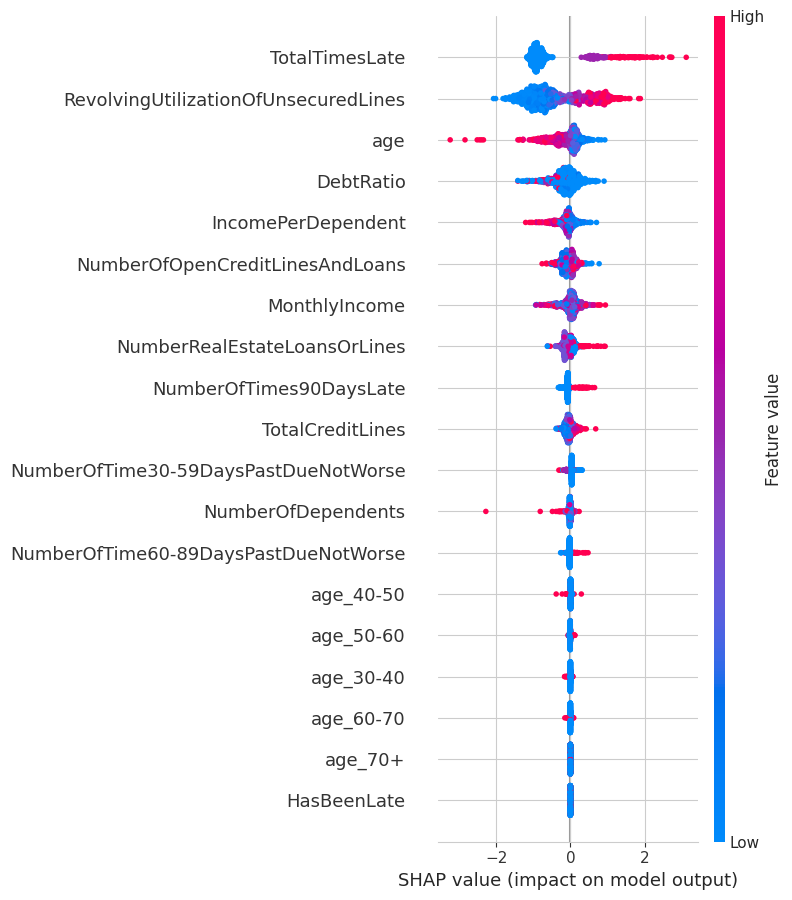

In [22]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_val.iloc[:1000])

shap.summary_plot(shap_values, X_val.iloc[:1000], show=False)
plt.tight_layout()
plt.show()

The chart above shows overall feature impact across many people. Below, I 
picked one specific person and explained their individual prediction the 
kind of explanation you could actually show to someone who was rejected.

Actual outcome: No Default
Predicted probability of default: 0.0449



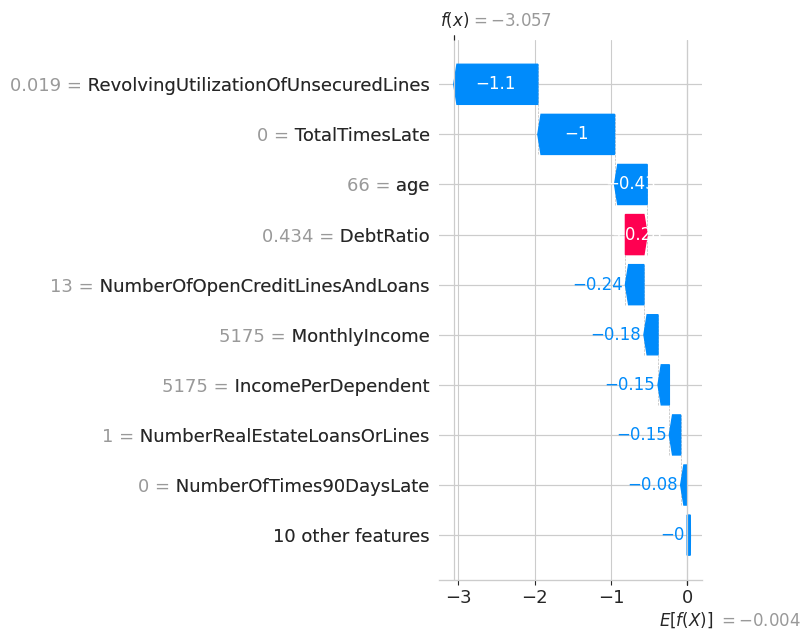

In [23]:
sample_idx = 0
print(f"Actual outcome: {'Default' if y_val.iloc[sample_idx] == 1 else 'No Default'}")
print(f"Predicted probability of default: {y_proba_xgb[sample_idx]:.4f}\n")

shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.tight_layout()
plt.show()

## 16. Adjusting the Decision Threshold
By default, models classify someone as "risky" if their predicted 
probability is above 0.5. But in lending, missing an actual defaulter is 
usually worse than a false alarm. So I looked at how precision and recall 
change at different threshold values, instead of just using 0.5 blindly.

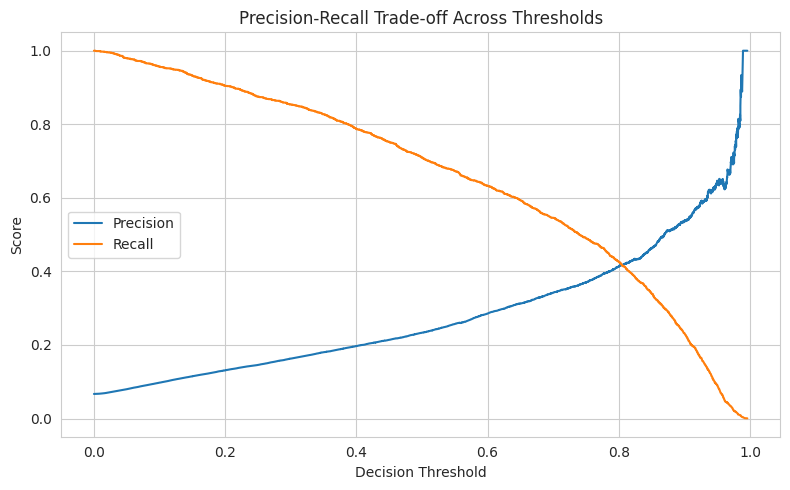

Threshold achieving >= 70% recall: 0.510
At this threshold - Precision: 0.2374, Recall: 0.7002


In [24]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_xgb)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off Across Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

# Example: threshold that guarantees at least 70% recall on defaulters
target_recall = 0.70
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
chosen_threshold = thresholds[valid_idx[-1]] if len(valid_idx) > 0 else 0.5

print(f"Threshold achieving >= {target_recall:.0%} recall: {chosen_threshold:.3f}")
print(f"At this threshold - Precision: {precisions[valid_idx[-1]]:.4f}, Recall: {recalls[valid_idx[-1]]:.4f}")

## 17. Conclusion

Here's what I found:

- **Random Forest beat Logistic Regression** on every important metric — 
  especially ROC-AUC and recall (catching actual defaulters)
- **Combining the late-payment columns into `TotalTimesLate` helped** — it 
  correlated more strongly with default than any single original column
- **`RevolvingUtilizationOfUnsecuredLines` was the most important feature** 
  for Random Forest, even though it barely showed any correlation on its 
  own — this means the relationship isn't a simple straight line, and only 
  a model like Random Forest could pick up on it
- **Cross-validation confirmed the results are stable**, not just a lucky 
  split
- Since missing a real defaulter is worse than a false alarm in lending, I 
  chose the model with higher recall, even though it means more false 
  alarms

**What I'd explore next:** trying more advanced tuning, testing on 
completely new data, and using SHAP more deeply to explain predictions for 
individual customers.

In [25]:
print("PROJECT COMPLETE — Credit Scoring Model")
print(f"Final model: Random Forest")
print(f"ROC-AUC: {auc_rf:.4f}")
print(f"Recall (Default class): {recall_score(y_val, y_pred_rf):.4f}")
print(f"Precision (Default class): {precision_score(y_val, y_pred_rf):.4f}")

PROJECT COMPLETE — Credit Scoring Model
Final model: Random Forest
ROC-AUC: 0.8659
Recall (Default class): 0.7501
Precision (Default class): 0.2324
